In [53]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "0"

# Path to root of this project, contains lots of modules
import sys
sys.path.insert(0, os.path.abspath('../'))
sys.path.insert(0, os.getcwd())

In [54]:
import math
import random
import numpy
from matplotlib import pyplot
from matplotlib import cm
from sklearn.preprocessing import StandardScaler
from tslearn.clustering import TimeSeriesKMeans
import torch
from torch import nn, optim

In [55]:
from src.learning_shapelets import LearningShapelets

In [56]:
# Import Python NumPy module
import numpy as np
import pandas as pd

# series = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\sktime-tutorial-pydata-global-2021\\notebooks\\univariatetest_data.csv', header=0, parse_dates=[0], index_col=0, squeeze=True)
# data = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\sktime-tutorial-pydata-global-2021\\notebooks\\test.csv')
series = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\Arduino_train_test_labels1.csv', header=0, parse_dates=[0], index_col=0, squeeze=True)


print(type(series))
print(series)


<class 'pandas.core.frame.DataFrame'>
           Work  Label
Time                  
0.0000     0.00      1
0.0500     0.00      1
0.1000     0.00      1
0.1500     0.00      1
0.2000     0.00      1
...         ...    ...
59.7494  664.02      0
59.7994  657.36      0
59.8494  652.91      0
59.8994  644.03      0
59.9494  640.47      0

[9600 rows x 2 columns]


C:\Users\dema2\AppData\Local\Temp\ipykernel_5224\1635252997.py:7: FutureWarning: The squeeze argument has been deprecated and will be removed in a future version. Append .squeeze("columns") to the call to squeeze.


  series = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\Arduino_train_test_labels1.csv', header=0, parse_dates=[0], index_col=0, squeeze=True)


In [57]:
new_array = series['Work'].to_numpy() 
y = series['Label'].to_numpy() 

In [58]:
print(new_array)
print(type(new_array))
print(new_array.shape)




y = y[~np.isnan(y)]
print(y.shape)
print(y)
print(type(y))


[  0.     0.     0.   ... 652.91 644.03 640.47]
<class 'numpy.ndarray'>
(9600,)
(9600,)
[1 1 1 ... 0 0 0]
<class 'numpy.ndarray'>


In [59]:
X = new_array.reshape(y.size,1,1)
print(X)

# y = y.astype('<U1')
np.unique(y)
print(X.shape)
print(y.shape)

[[[  0.  ]]

 [[  0.  ]]

 [[  0.  ]]

 ...

 [[652.91]]

 [[644.03]]

 [[640.47]]]
(9600, 1, 1)
(9600,)


[Text(0, 0.5, 'Scaled distance from midpoint'), Text(0.5, 0, 'Index')]

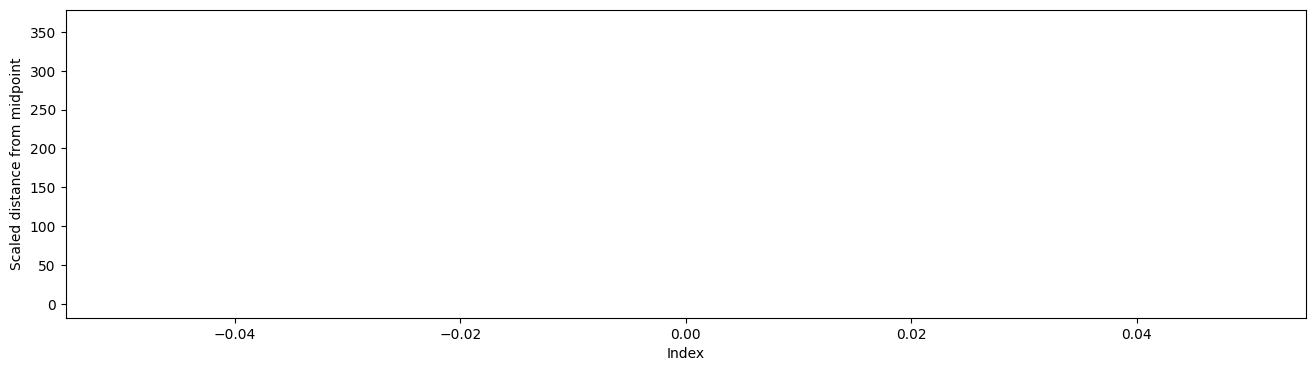

In [60]:
import matplotlib.pyplot as plt

labels, counts = np.unique(y, return_counts=True)
fig, ax = plt.subplots(1, figsize=plt.figaspect(0.25))

for label in labels:
    ax.plot(X[y == label, 0, :][0], label=f"class {label}")
ax.set(ylabel="Scaled distance from midpoint", xlabel="Index")

In [61]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

print(X_train)
print(X_test)
print(y_train)
print(y_test)

[[[1409.6 ]]

 [[ 880.21]]

 [[ 408.02]]

 ...

 [[1432.67]]

 [[ 693.04]]

 [[ 720.54]]]
[[[   0.  ]]

 [[1013.98]]

 [[1024.19]]

 ...

 [[1102.74]]

 [[ 733.37]]

 [[1634.35]]]
[3 6 3 ... 0 5 3]
[1 4 4 ... 7 7 0]


In [62]:
def sample_ts_segments(X, shapelets_size, n_segments=10000):
    """
    Sample time series segments for k-Means.
    """
    n_ts, n_channels, len_ts = X.shape
    samples_i = random.choices(range(n_ts), k=n_segments)
    segments = numpy.empty((n_segments, n_channels, shapelets_size))
    for i, k in enumerate(samples_i):
        s = random.randint(0, len_ts - shapelets_size)
        segments[i] = X[k, :, s:s+shapelets_size]
    return segments

print(X.shape)

(9600, 1, 1)


In [63]:
def get_weights_via_kmeans(X, shapelets_size, num_shapelets, n_segments=10000):
    """
    Get weights via k-Means for a block of shapelets.
    """
    segments = sample_ts_segments(X, shapelets_size, n_segments).transpose(0, 2, 1)
    k_means = TimeSeriesKMeans(n_clusters=num_shapelets, metric="euclidean", max_iter=50).fit(segments)
    clusters = k_means.cluster_centers_.transpose(0, 2, 1)
    return clusters

In [64]:
n_ts, n_channels, len_ts = X_train.shape
loss_func = nn.CrossEntropyLoss()
num_classes = len(set(y_train))
# learn 2 shapelets of length 130
shapelets_size_and_len = {1: 5000}
dist_measure = "euclidean"
lr = 1e-2
wd = 1e-3
epsilon = 1e-7



In [65]:
learning_shapelets = LearningShapelets(shapelets_size_and_len=shapelets_size_and_len,
                                       in_channels=n_channels,
                                       num_classes=num_classes,
                                       loss_func=loss_func,
                                       to_cuda=False,
                                       verbose=1,
                                       dist_measure=dist_measure)

In [66]:
for i, (shapelets_size, num_shapelets) in enumerate(shapelets_size_and_len.items()):
    weights_block = get_weights_via_kmeans(X_train, shapelets_size, num_shapelets)
    learning_shapelets.set_shapelet_weights_of_block(i, weights_block)

In [67]:
optimizer = optim.Adam(learning_shapelets.model.parameters(), lr=lr, weight_decay=wd, eps=epsilon)
learning_shapelets.set_optimizer(optimizer)

In [68]:
losses = learning_shapelets.fit(X_train, y_train, epochs=2000, batch_size=256, shuffle=False, drop_last=False)

Loss: 2965.2822265625: 100%|██████████| 2000/2000 [12:17:50<00:00, 22.14s/it]          


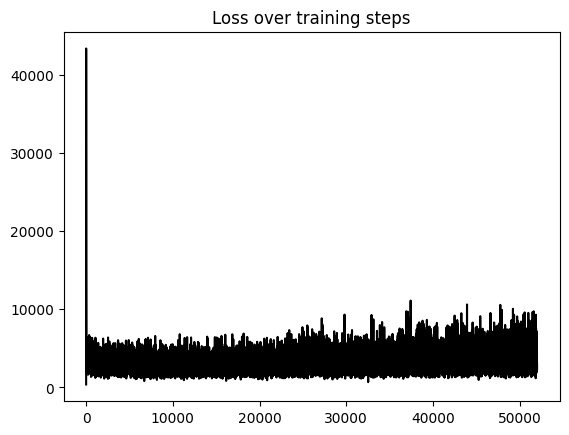

In [69]:
pyplot.plot(losses, color='black')
pyplot.title("Loss over training steps")
pyplot.show()

In [70]:
def eval_accuracy(model, X, Y):
    predictions = model.predict(X)
    if len(predictions.shape) == 2:
        predictions = predictions.argmax(axis=1)
        print(predictions)
    print(f"Accuracy: {(predictions == Y).sum() / Y.size}")

In [71]:
eval_accuracy(learning_shapelets, X_test, y_test)
# print(X_test)
print(y_test)



[1 4 4 ... 4 7 4]
Accuracy: 0.4147727272727273
[1 4 4 ... 7 7 0]


In [72]:
test = np.array([[[ 2,  3,  4,  4]]])
# print(type(test))
test_pred = learning_shapelets.predict(test)
print(test_pred.argmax())


1
